# AMI Dataset Preprocessing

Одноразовий скрипт: нарізає довгі AMI-записи на короткі чанки і зберігає їх у `data/{train,val,test}/`.  
Після виконання головний notebook читає лише готові чанки — більше не потрібно чіпати `ami_data/`.

**Параметри нарізки** (змінюй тут):
| Параметр | Значення | Пояснення |
|---|---|---|
| `CHUNK_SEC` | 5 | тривалість чанка |
| `STEP_SEC` | 2.5 | крок sliding window (50% overlap) |
| `SR` | 16000 | sample rate |
| `MAX_SPEAKERS` | 4 | макс. мовців у мітці сегментації (PIT-CE) |

In [6]:
import datasets
from datasets import Audio
import numpy as np
import json
import soundfile as sf
import io
from pathlib import Path
from tqdm.auto import tqdm

# ── параметри ──────────────────────────────────────────────
DATA_DIR     = Path("ami_data")
OUT_DIR      = Path("data")
CHUNK_SEC    = 5.0
STEP_SEC     = 2.5
SR           = 16000
MAX_SPEAKERS = 4
FRAME_SHIFT  = 0.01
# ───────────────────────────────────────────────────────────

CHUNK_SAMPLES = int(CHUNK_SEC * SR)
STEP_SAMPLES  = int(STEP_SEC  * SR)
N_FRAMES      = int(CHUNK_SEC / FRAME_SHIFT)

def decode_audio(example):
    raw = example['audio']
    audio_bytes = raw.get('bytes') or open(raw['path'], 'rb').read()
    array, sr = sf.read(io.BytesIO(audio_bytes), dtype='float32', always_2d=False)
    return array, sr

print(f"Chunk: {CHUNK_SEC}s = {CHUNK_SAMPLES} samples, {N_FRAMES} frames")
print(f"Step : {STEP_SEC}s  = {STEP_SAMPLES} samples")

Chunk: 5.0s = 80000 samples, 500 frames
Step : 2.5s  = 40000 samples


## Допоміжні функції

In [7]:
def build_frame_labels(starts, ends, speakers, chunk_start_s, n_frames, frame_shift, max_spk):
    vad = np.zeros(n_frames, dtype=np.float32)
    seg = np.zeros((n_frames, max_spk), dtype=np.float32)

    chunk_end_s = chunk_start_s + n_frames * frame_shift
    local_spk = {}
    for s, e, sp in zip(starts, ends, speakers):
        if e <= chunk_start_s or s >= chunk_end_s:
            continue
        if sp not in local_spk and len(local_spk) < max_spk:
            local_spk[sp] = len(local_spk)

    for s, e, sp in zip(starts, ends, speakers):
        if sp not in local_spk:
            continue
        cs = max(s, chunk_start_s) - chunk_start_s
        ce = min(e, chunk_end_s)   - chunk_start_s
        fi = int(cs / frame_shift)
        fe = min(int(ce / frame_shift) + 1, n_frames)
        if fi >= fe:
            continue
        vad[fi:fe] = 1.0
        seg[fi:fe, local_spk[sp]] = 1.0

    return vad, seg, local_spk

## Запуск preprocessing

In [8]:
def load_ami(data_dir):
    splits = {}
    for split_name, prefix in [('train', 'train'), ('validation', 'validation'), ('test', 'test')]:
        shards = sorted(data_dir.glob(f"ami-{prefix}-*.arrow"))
        parts = [datasets.Dataset.from_file(str(f)) for f in shards]
        ds_split = datasets.concatenate_datasets(parts)
        ds_split = ds_split.cast_column("audio", Audio(decode=False))
        splits[split_name] = ds_split
    return datasets.DatasetDict(splits)

ds = load_ami(DATA_DIR)
print(ds)

DatasetDict({
    train: Dataset({
        features: ['audio', 'timestamps_start', 'timestamps_end', 'speakers'],
        num_rows: 136
    })
    validation: Dataset({
        features: ['audio', 'timestamps_start', 'timestamps_end', 'speakers'],
        num_rows: 18
    })
    test: Dataset({
        features: ['audio', 'timestamps_start', 'timestamps_end', 'speakers'],
        num_rows: 16
    })
})


In [9]:
def process_split(split_ds, split_name):
    out = OUT_DIR / split_name
    out.mkdir(parents=True, exist_ok=True)

    chunk_meta = []
    chunk_idx  = 0
    skipped    = 0

    for rec_idx, example in enumerate(tqdm(split_ds, desc=split_name)):
        # пропускаємо записи де не рівно 4 спікери
        if len(set(example['speakers'])) != MAX_SPEAKERS:
            skipped += 1
            continue

        audio, _ = decode_audio(example)
        starts  = example['timestamps_start']
        ends    = example['timestamps_end']
        spkrs   = example['speakers']
        n_samples = len(audio)

        offset = 0
        while offset + CHUNK_SAMPLES <= n_samples:
            chunk_audio   = audio[offset: offset + CHUNK_SAMPLES]
            chunk_start_s = offset / SR

            vad, seg, spk_map = build_frame_labels(
                starts, ends, spkrs,
                chunk_start_s, N_FRAMES, FRAME_SHIFT, MAX_SPEAKERS
            )

            fname = out / f"{chunk_idx:07d}.npz"
            np.savez_compressed(fname, audio=chunk_audio, vad=vad, seg=seg)

            chunk_meta.append({
                "chunk_id"    : chunk_idx,
                "rec_idx"     : rec_idx,
                "start_s"     : round(chunk_start_s, 3),
                "speakers"    : list(spk_map.keys()),
                "speech_ratio": float(vad.mean()),
            })

            chunk_idx += 1
            offset += STEP_SAMPLES

    meta_path = out / "meta.json"
    with open(meta_path, "w") as f:
        json.dump({"params": {
                       "chunk_sec": CHUNK_SEC, "step_sec": STEP_SEC,
                       "sr": SR, "max_speakers": MAX_SPEAKERS,
                       "n_frames": N_FRAMES, "frame_shift": FRAME_SHIFT},
                   "chunks": chunk_meta}, f, indent=2)

    speech_ratios = [c["speech_ratio"] for c in chunk_meta]
    print(f"  {split_name}: {chunk_idx} chunks → {out}  (skipped {skipped} recs ≠ 4 spk)")
    print(f"    speech ratio mean={np.mean(speech_ratios):.2f}, "
          f"silence chunks (<5%): {sum(r<0.05 for r in speech_ratios)}")
    return chunk_meta

In [10]:
meta_train = process_split(ds['train'],      'train')
meta_val   = process_split(ds['validation'], 'val')
meta_test  = process_split(ds['test'],       'test')

print("\nDone. Structure:")
for split in ['train', 'val', 'test']:
    n = len(list((OUT_DIR / split).glob('*.npz')))
    print(f"  data/{split}/  → {n} .npz files")

train:   0%|          | 0/136 [00:00<?, ?it/s]

  train: 106317 chunks → data/train  (skipped 7 recs ≠ 4 spk)
    speech ratio mean=0.82, silence chunks (<5%): 6055


val:   0%|          | 0/18 [00:00<?, ?it/s]

  val: 13895 chunks → data/val  (skipped 0 recs ≠ 4 spk)
    speech ratio mean=0.79, silence chunks (<5%): 991


test:   0%|          | 0/16 [00:00<?, ?it/s]

  test: 11838 chunks → data/test  (skipped 1 recs ≠ 4 spk)
    speech ratio mean=0.80, silence chunks (<5%): 743

Done. Structure:
  data/train/  → 106317 .npz files
  data/val/  → 13895 .npz files
  data/test/  → 11838 .npz files


## Перевірка: заглянути в один чанк

audio : (80000,)  (samples)
vad   : (500,)    (frames), speech=1.00
seg   : (500, 4)    (frames × max_speakers)


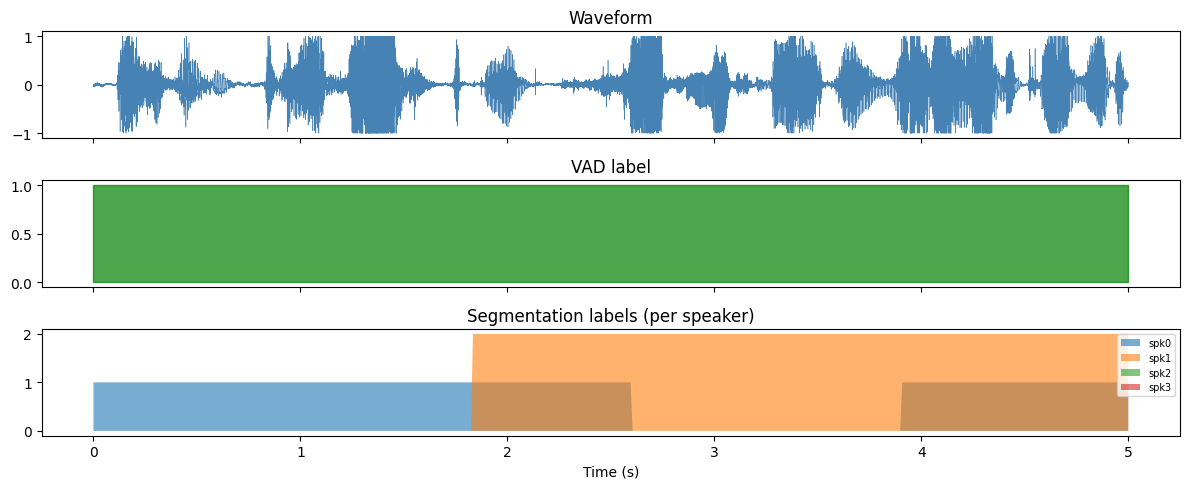

In [12]:
import matplotlib.pyplot as plt
import IPython.display as ipd

sample = np.load(OUT_DIR / 'train' / '0000086.npz')
audio = sample['audio']
vad   = sample['vad']
seg   = sample['seg']

print(f"audio : {audio.shape}  (samples)")
print(f"vad   : {vad.shape}    (frames), speech={vad.mean():.2f}")
print(f"seg   : {seg.shape}    (frames × max_speakers)")

t_audio  = np.linspace(0, CHUNK_SEC, len(audio))
t_frames = np.linspace(0, CHUNK_SEC, len(vad))

fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True)
axes[0].plot(t_audio, audio, linewidth=0.4, color='steelblue')
axes[0].set_title('Waveform')
axes[1].fill_between(t_frames, vad, alpha=0.7, color='green')
axes[1].set_title('VAD label')
axes[1].set_ylim(-0.05, 1.05)
for i in range(MAX_SPEAKERS):
    axes[2].fill_between(t_frames, seg[:, i] * (i + 1),
                         alpha=0.6, label=f'spk{i}')
axes[2].set_title('Segmentation labels (per speaker)')
axes[2].set_xlabel('Time (s)')
axes[2].legend(loc='upper right', fontsize=7)
plt.tight_layout()
plt.show()

ipd.display(ipd.Audio(audio, rate=SR))